## در این مثال داده های جمع آوری شده از چند ایستگاه پایش محیط زیست شهرداری بیجینگ چین استفاده شده است. بازه دیتاست از ۱ مارس ۲۰۱۳ الی ۲۸ فوریه ۲۰۱۷ است. داده ها را از طریق لینک زیر دانلود و در پوشه کاری استخراج کنید
https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-8/PRSA2017_Data_20130301-20170228.zip

در این مثال، ابتدا داده ها در یک فایل تجمیع می شوند و پس از پیش پردازش داده با استفاده از Optuna ابرپارامترهای لازم برای مدل سازی توسط XGBoost بهینه سازی می شوند.
هدف در این مثال پیش بینی غلظت آلاینده Co یا NO2 با استفاده از الگوریتم XGBoost  می باشد.

### نصب کتابخانه های مورد نیاز

In [1]:
!pip install optuna xgboost glob2 plotly

### فراخوانی کتابخانه های مورد نیاز

In [2]:
import os
import pandas as pd
import numpy as np
import json
from glob import glob
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import joblib

from arabic_reshaper import reshape
from bidi.algorithm import get_display

### تعریف پارامترها و توابع کمکی

In [3]:
# مسیر پوشه ای که فایل های اکسل در آن قرار دارند
INPUT_FOLDER = "PRSA_Data_20130301-20170228"  
OUTPUT_FILE = "merged_data.csv"
OUTPUT_MODEL = "model.joblib"
BEST_PARAMS_JSON = "best_params.json"
RANDOM_SEED = 42
TARGET = 'CO'  # 'CO' يا 'NO2' را اينجا انتخاب کنيد
TEST_SIZE = 0.2  # بخش آخر داده ها (زمانی) برای تست
N_TRIALS = 50
N_SPLITS_CV = 5

# تابع تبدیل متن فارسی برای نمایش در نمودارها
def fa(text):
    reshaped_text = reshape(text)
    return get_display(reshaped_text)

# تنظیمات فارسی نویسی
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

### بارگزاری داده ها و تجمیع در یک فایل

In [4]:
# همه فایل های CSV در پوشه
csv_files = [f for f in os.listdir(INPUT_FOLDER) if f.endswith('.csv')]

# لیست برای نگهداری دیتاها
dfs = []

for file in csv_files:
    file_path = os.path.join(INPUT_FOLDER, file)
    df = pd.read_csv(file_path)
    dfs.append(df)

# ادغام همه فایل ها پشت سر هم
merged_df = pd.concat(dfs, ignore_index=True)

# ذخیره در فایل خروجی
if not os.path.exists(OUTPUT_FILE):
    merged_df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

merged_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong


### پیش پردازش داده

In [5]:
# ستون هايي که انتظار داريم
EXPECTED_COLS = ["No","year","month","day","hour","PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","wd","WSPM","station"]

print("تعداد گمشده در ستون ها:", merged_df.isna().sum()) # بررسی وجود گمشده در داده ها
df = merged_df.interpolate() # سناریو درون یابی گمشده ها
print("تعداد گمشده در ستون ها بعد از درون یابی:", df.isna().sum()) # بررسی وجود گمشده در داده های ویرایش شده
df = df.dropna() # اگر هنوز ستونی دارای گمشده است، حذف شود
print("ابعاد داده قبلی:",merged_df.shape,"ابعاد داده جدید:", df.shape)

def preprocess(df: pd.DataFrame, target: str):
    # اطمینان از ستون ها
    missing = [c for c in EXPECTED_COLS if c not in df.columns]
    if missing:
        print(f"هشدار: ستون های زیر در داده ها وجود ندارند: {missing}")

    # تبدیل ستون های تاریخ/زمان
    # اگر ستون year/month/day/hour عددی است
    df['year'] = df['year'].astype(int)
    df['month'] = df['month'].astype(int)
    df['day'] = df['day'].astype(int)
    df['hour'] = df['hour'].astype(int)
    df['datetime'] = pd.to_datetime(df[['year','month','day','hour']].rename(columns={'hour':'hour'}), errors='coerce')

    # مرتب سازی زمانی
    df = df.sort_values('datetime').reset_index(drop=True)

    # تولید ویژگی های زمانی چرخه ای
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # پاک سازی ستون های غیرضروری
    drop_cols = ['No']
    for c in drop_cols:
        if c in df.columns:
            df = df.drop(columns=[c])

    # تبدیل wd (جهت باد) اگر به شکل عددی است نگه دارید، اگر رشته است آن را one-hot کنید
    if 'wd' in df.columns:
        if df['wd'].dtype == object:
            # اگر تعداد دسته ها زیاد است، فقط top-k
            topk = 20
            top_vals = df['wd'].value_counts().index[:topk]
            df['wd'] = df['wd'].where(df['wd'].isin(top_vals), other='other')
            df = pd.get_dummies(df, columns=['wd'], prefix='wd')
        else:
            # فرض کنیم wd درجه است؛ از تبدیل چرخه ای استفاده کنید
            try:
                df['wd'] = pd.to_numeric(df['wd'], errors='coerce')
                df['wd_sin'] = np.sin(2 * np.pi * df['wd'] / 360)
                df['wd_cos'] = np.cos(2 * np.pi * df['wd'] / 360)
                df = df.drop(columns=['wd'])
            except Exception:
                pass

    # ایندکس زمانی
    df = df.set_index('datetime')

    # انتخاب ویژگی ها (حذف هدف و ستون های ردیف)
    features = [c for c in df.columns if c != target and c != 'station' and c != 'year' and c != 'month' and c != 'day' and c != 'hour']

    # مقادیر عددی تبدیل
    # پر کردن مقادیر گمشده با میانه (برای عددی)
    num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    df[num_cols] = imputer.fit_transform(df[num_cols])

    # اگر ویژگی های غیرعددی داریم، one-hot انجام شده است یا حذف می شود
    # مقیاس دهی
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    # نهایی سازی X و y
    X = df[features]
    y = df[target].astype(float)

    return X, y, scaler, imputer


if TARGET not in df.columns:
        raise ValueError(f"ستون هدف {TARGET} در داده ها وجود ندارد. ستون ها: {df.columns.tolist()}")

X, y, scaler, imputer = preprocess(df, TARGET)

# تقسیم زمانی به train/test (آخرین بخش داده برای تست)
n_test = int(len(X) * TEST_SIZE)
if n_test < 1:
        raise ValueError("حجم داده برای تست بسیار کوچک است. TEST_SIZE را افزایش دهید یا داده بیشتری وارد کنید.")

X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

X_train.head()

تعداد گمشده در ستون ها: No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64
تعداد گمشده در ستون ها بعد از درون یابی: No            0
year          0
month         0
day           0
hour          0
PM2.5         0
PM10          0
SO2           0
NO2           0
CO            0
O3            0
TEMP          0
PRES          0
DEWP          0
RAIN          0
wd         1822
WSPM          0
station       0
dtype: int64
ابعاد داده قبلی: (420768, 18) ابعاد داده جدید: (418946, 18)
Train shape: (335157, 30), Test shape: (83789, 30)


,PM2.5,PM10,SO2,NO2,O3,TEMP,PRES,DEWP,RAIN,WSPM,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
datetime,,,,,,,,,,,,,,,,,,,,,
2013-03-01,-0.936158,-1.091354,-0.544136,-1.238850,0.343210,-1.247183,1.170991,-1.542720,-0.078553,2.140786,...,True,False,False,False,False,False,False,False,False,False
2013-03-01,-0.936158,-1.091354,-0.589762,-0.888049,0.430655,-1.387102,0.960975,-1.607931,-0.078553,-0.992244,...,False,False,False,False,False,False,False,False,False,False
2013-03-01,-0.874366,-1.037241,-0.589762,-0.954416,0.553077,-1.229693,1.314185,-1.731106,-0.078553,3.185130,...,True,False,False,False,False,False,False,False,False,False
2013-03-01,-0.936158,-1.091354,-0.087877,-0.869086,0.203300,-1.247183,1.170991,-1.542720,-0.078553,2.140786,...,True,False,False,False,False,False,False,False,False,False
2013-03-01,-0.911441,-0.939838,-0.498510,0.004531,0.535588,-1.177223,0.989613,-1.528229,-0.078553,2.140786,...,False,True,False,False,False,False,False,False,False,False


### مدل سازی با بهینه سازی ابرپارامترها

In [6]:
# ابتدا ابرپارامترها
def objective(trial, X, y):
    params = {                     # تعریف بازه ابرپارامترهای اپتیما جهت یافتن بهترین پارامترهای برای XGBoost 
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'booster': 'gbtree',
        'tree_method': 'auto',
        'seed': RANDOM_SEED,
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 10.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20)
    }

    # TimeSeries CV
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
    rmses = []
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(**params, early_stopping_rounds = 30)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        rmse = mean_squared_error(y_val, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))


# اجرای Optuna
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
func = lambda trial: objective(trial, X_train, y_train)
study.optimize(func, n_trials=N_TRIALS)
print("Best RMSE:", study.best_value)
print("Best params:")
print(study.best_params)

# ذخیره پارامترها
with open(BEST_PARAMS_JSON, 'w') as f:
        json.dump({'best_value': study.best_value, 'best_params': study.best_params}, f, indent=2)

[I 2025-09-19 06:00:15,218] A new study created in memory with name: no-name-73d87be3-fb09-45b4-a16e-d21c638ba7db
[I 2025-09-19 06:01:05,119] Trial 0 finished with value: 570.7901761023766 and parameters: {'n_estimators': 812, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.40921304830970556, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 18}. Best is trial 0 with value: 570.7901761023766.
[I 2025-09-19 06:05:41,061] Trial 1 finished with value: 654.5047973139328 and parameters: {'n_estimators': 1242, 'max_depth': 10, 'learning_rate': 0.001124579825911934, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.8827098485602951, 'reg_alpha': 8.148018307012941e-07, 'reg_lambda': 4.329370014459266e-07, 'min_child_weight': 4}. Best is trial 0 with value: 570.7901761023766.
[I 2025-09-19 06:06:51,845] Trial 2 finished with value: 549.1745836399862 and parameters: {'n_estimators': 67

[I 2025-09-19 06:22:47,120] Trial 22 finished with value: 546.3655588454935 and parameters: {'n_estimators': 1805, 'max_depth': 3, 'learning_rate': 0.08001236323576583, 'subsample': 0.5366254970741664, 'colsample_bytree': 0.9152042922839828, 'reg_alpha': 0.7545153935346922, 'reg_lambda': 2.86707292472998, 'min_child_weight': 18}. Best is trial 10 with value: 540.2131594627808.
[I 2025-09-19 06:23:08,294] Trial 23 finished with value: 543.539767952966 and parameters: {'n_estimators': 1466, 'max_depth': 4, 'learning_rate': 0.16551879459129973, 'subsample': 0.7814154168201569, 'colsample_bytree': 0.989821358599952, 'reg_alpha': 0.07144186215361163, 'reg_lambda': 0.006417711426197863, 'min_child_weight': 20}. Best is trial 10 with value: 540.2131594627808.
[I 2025-09-19 06:23:48,740] Trial 24 finished with value: 545.9877865479745 and parameters: {'n_estimators': 1847, 'max_depth': 6, 'learning_rate': 0.04261197000405512, 'subsample': 0.8449638608200779, 'colsample_bytree': 0.9377474807613

[I 2025-09-19 06:35:40,029] Trial 44 finished with value: 547.331892519172 and parameters: {'n_estimators': 1996, 'max_depth': 4, 'learning_rate': 0.2976562756979103, 'subsample': 0.8085705417728623, 'colsample_bytree': 0.9003518059082667, 'reg_alpha': 0.6090830932301968, 'reg_lambda': 1.266785378340494e-07, 'min_child_weight': 17}. Best is trial 31 with value: 537.2473395184146.
[I 2025-09-19 06:36:14,177] Trial 45 finished with value: 540.0123841311395 and parameters: {'n_estimators': 1686, 'max_depth': 3, 'learning_rate': 0.20837837687449434, 'subsample': 0.7416696462142269, 'colsample_bytree': 0.8398795948303734, 'reg_alpha': 0.034796452788031264, 'reg_lambda': 3.3500064047841135e-05, 'min_child_weight': 18}. Best is trial 31 with value: 537.2473395184146.
[I 2025-09-19 06:36:34,385] Trial 46 finished with value: 549.235569299475 and parameters: {'n_estimators': 1732, 'max_depth': 9, 'learning_rate': 0.10226660922156183, 'subsample': 0.750334329272111, 'colsample_bytree': 0.8357387

Best RMSE: 537.2473395184146
Best params:
{'n_estimators': 1091, 'max_depth': 4, 'learning_rate': 0.1887065374701864, 'subsample': 0.7447095130370407, 'colsample_bytree': 0.9510203089068363, 'reg_alpha': 1.8687770042794583, 'reg_lambda': 3.863651673415472e-05, 'min_child_weight': 19}


### مدل سازی با پارامترهای بهینه شده

In [8]:
# آموزش مدل نهایی با کل دادهٔ آموزشی
best_params = study.best_params
# اضافه کردن پارامترهای ثابت
best_params.update({'verbosity':0, 'objective':'reg:squarederror', 'seed':RANDOM_SEED})

final_model = xgb.XGBRegressor(**best_params, early_stopping_rounds = 30)
final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)

# ارزیابی
preds_test = final_model.predict(X_test)
rmse = mean_squared_error(y_test, preds_test, squared=False)
mae = mean_absolute_error(y_test, preds_test)
r2 = r2_score(y_test, preds_test)

print('\n--- Test Results ---')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')

# ذخیره مدل
joblib.dump(final_model, OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

[0]	validation_0-rmse:1126.47992
[1]	validation_0-rmse:989.84336
[2]	validation_0-rmse:881.22285
[3]	validation_0-rmse:795.50888
[4]	validation_0-rmse:735.08089
[5]	validation_0-rmse:692.54664
[6]	validation_0-rmse:656.79144
[7]	validation_0-rmse:627.37380
[8]	validation_0-rmse:608.03581
[9]	validation_0-rmse:592.21643
[10]	validation_0-rmse:580.72402
[11]	validation_0-rmse:572.12860
[12]	validation_0-rmse:564.80669
[13]	validation_0-rmse:560.21159
[14]	validation_0-rmse:556.49112
[15]	validation_0-rmse:551.35865
[16]	validation_0-rmse:548.15513
[17]	validation_0-rmse:543.28624
[18]	validation_0-rmse:541.80014
[19]	validation_0-rmse:541.64757
[20]	validation_0-rmse:540.16493
[21]	validation_0-rmse:539.02940
[22]	validation_0-rmse:537.77850
[23]	validation_0-rmse:537.35839
[24]	validation_0-rmse:537.05364
[25]	validation_0-rmse:537.27212
[26]	validation_0-rmse:536.52891
[27]	validation_0-rmse:536.23651
[28]	validation_0-rmse:535.59826
[29]	validation_0-rmse:535.78144
[30]	validation_0-r

[245]	validation_0-rmse:510.95460
[246]	validation_0-rmse:510.89352
[247]	validation_0-rmse:510.78486
[248]	validation_0-rmse:510.91567
[249]	validation_0-rmse:510.79795
[250]	validation_0-rmse:510.80842
[251]	validation_0-rmse:510.75767
[252]	validation_0-rmse:510.76969
[253]	validation_0-rmse:510.77179
[254]	validation_0-rmse:510.53051

--- Test Results ---
RMSE: 510.3075
MAE: 292.0840
R2: 0.8454
Model saved to model.joblib


### مصورسازی

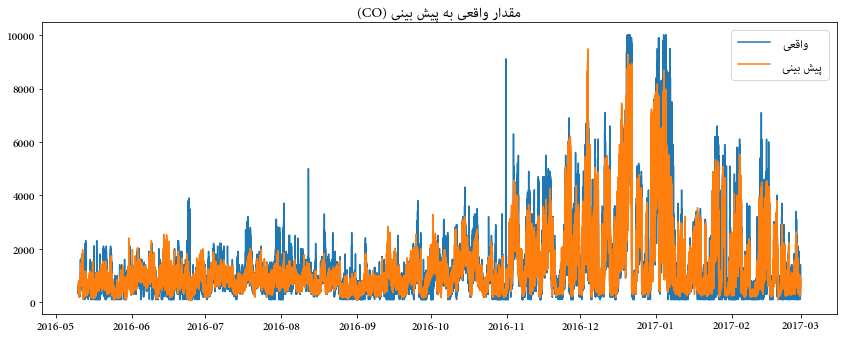

In [9]:
# نمودار واقعی vs پیش بینی
plt.figure(figsize=(12,5))
plt.plot(y_test.index.to_numpy(), y_test.values, label=fa('واقعی'))
plt.plot(y_test.index.to_numpy(), preds_test, label=fa('پیش بینی'))
plt.legend()
plt.title(fa(f'مقدار واقعی به پیش بینی ({TARGET})'))
plt.tight_layout()
plt.show()

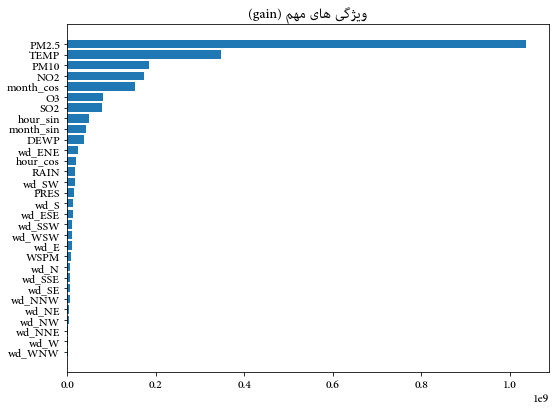

In [10]:
# اهمیت ویژگی
try:
    importance = final_model.get_booster().get_score(importance_type='gain')
    items = sorted(importance.items(), key=lambda x: x[1], reverse=True)
    feat_names = [k for k,v in items]
    scores = [v for k,v in items]
    plt.figure(figsize=(8,6))
    plt.barh(feat_names, scores)
    plt.gca().invert_yaxis()
    plt.title(fa('ویژگی های مهم (gain)'))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('ناموفق در نمایش ویژگی های مهم:', e)